# Feature correlation analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../data')

NUMERIC = [
    'temperature', 'humidity', 'wind_speed', 'precipitation', 'ndvi',
    'temperature_7d', 'humidity_7d', 'wind_speed_7d', 'precipitation_7d', 'ndvi_7d',
    'fwi', 'fwi_7d',
    'temperature_anom', 'humidity_anom', 'wind_speed_anom', 'precipitation_anom', 'ndvi_anom',
    'population', 'gdp_per_capita', 'infrastructure_density',
]

df   = pd.read_csv(DATA / 'features.csv')
corr = df[NUMERIC].corr()
df.head()

,date,lat,lon,burned_area_ha,duration_days,ignition_cause,target,temperature,humidity,wind_speed,...,temperature_anom,humidity_anom,wind_speed_anom,precipitation_anom,ndvi_anom,land_use,municipality_id,population,gdp_per_capita,infrastructure_density
0,2014-04-12,37.6327,13.8367,26.9,2,human,1,25.370170,61.240948,7.351485,...,-0.861324,1.217022,0.133213,-0.210131,-0.005837,forest,MUN_222,6754.0,30771.0,2.93
1,2014-04-14,44.1633,16.0408,24.9,1,lightning,1,20.885391,51.293873,4.670995,...,-0.466951,1.122852,-0.105313,-0.613541,-0.005140,water,MUN_044,6063.0,34423.0,4.24
2,2014-04-26,37.0204,9.9184,24.8,1,human,1,28.029165,57.961080,7.653720,...,1.727047,-2.162418,0.394655,-0.205526,0.025094,shrubland,MUN_112,1687.0,13749.0,1.79
3,2014-04-26,45.1837,14.3265,26.1,1,unknown,1,21.740004,44.521980,4.208980,...,1.859949,-2.727554,0.187562,-0.393211,0.026404,agricultural,MUN_101,50951.0,19511.0,10.41
4,2014-04-28,44.9796,15.5510,51.6,1,human,1,23.132423,46.239494,4.701382,...,2.422821,-2.677616,0.261895,-0.498505,0.041554,agricultural,MUN_167,9827.0,39140.0,4.61


## Full correlation heatmap

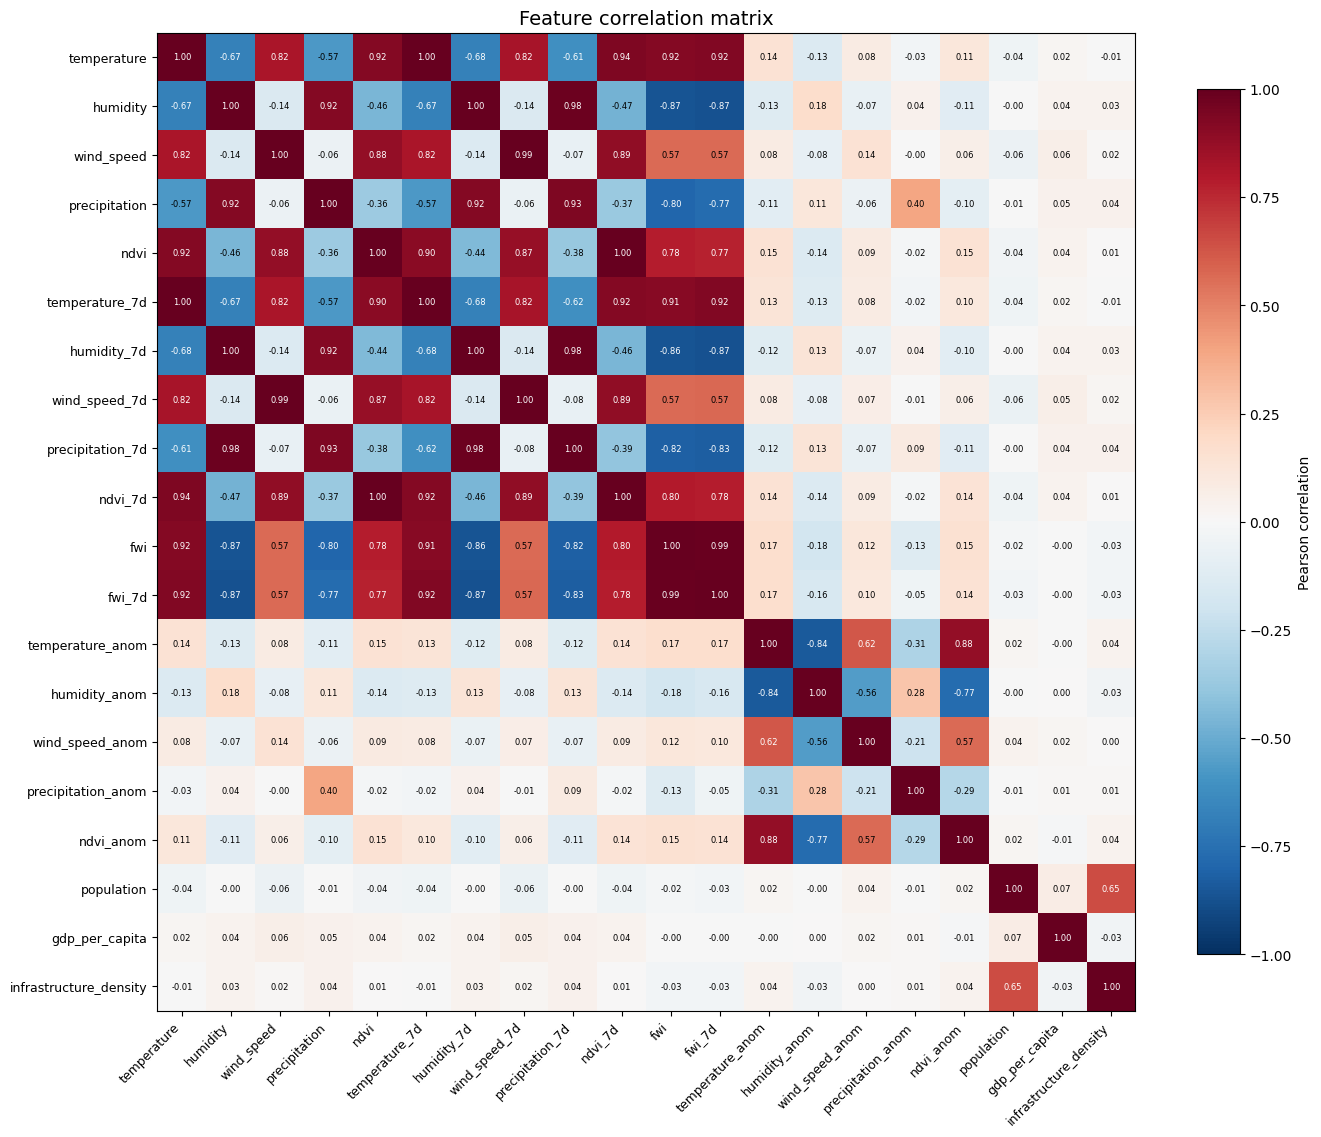

In [4]:
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson correlation')

ax.set_xticks(range(len(NUMERIC)))
ax.set_yticks(range(len(NUMERIC)))
ax.set_xticklabels(NUMERIC, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(NUMERIC, fontsize=9)

for i in range(len(NUMERIC)):
    for j in range(len(NUMERIC)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

ax.set_title('Feature correlation matrix', fontsize=14)
plt.tight_layout()
plt.show()

## Highly correlated pairs (|r| > 0.70)

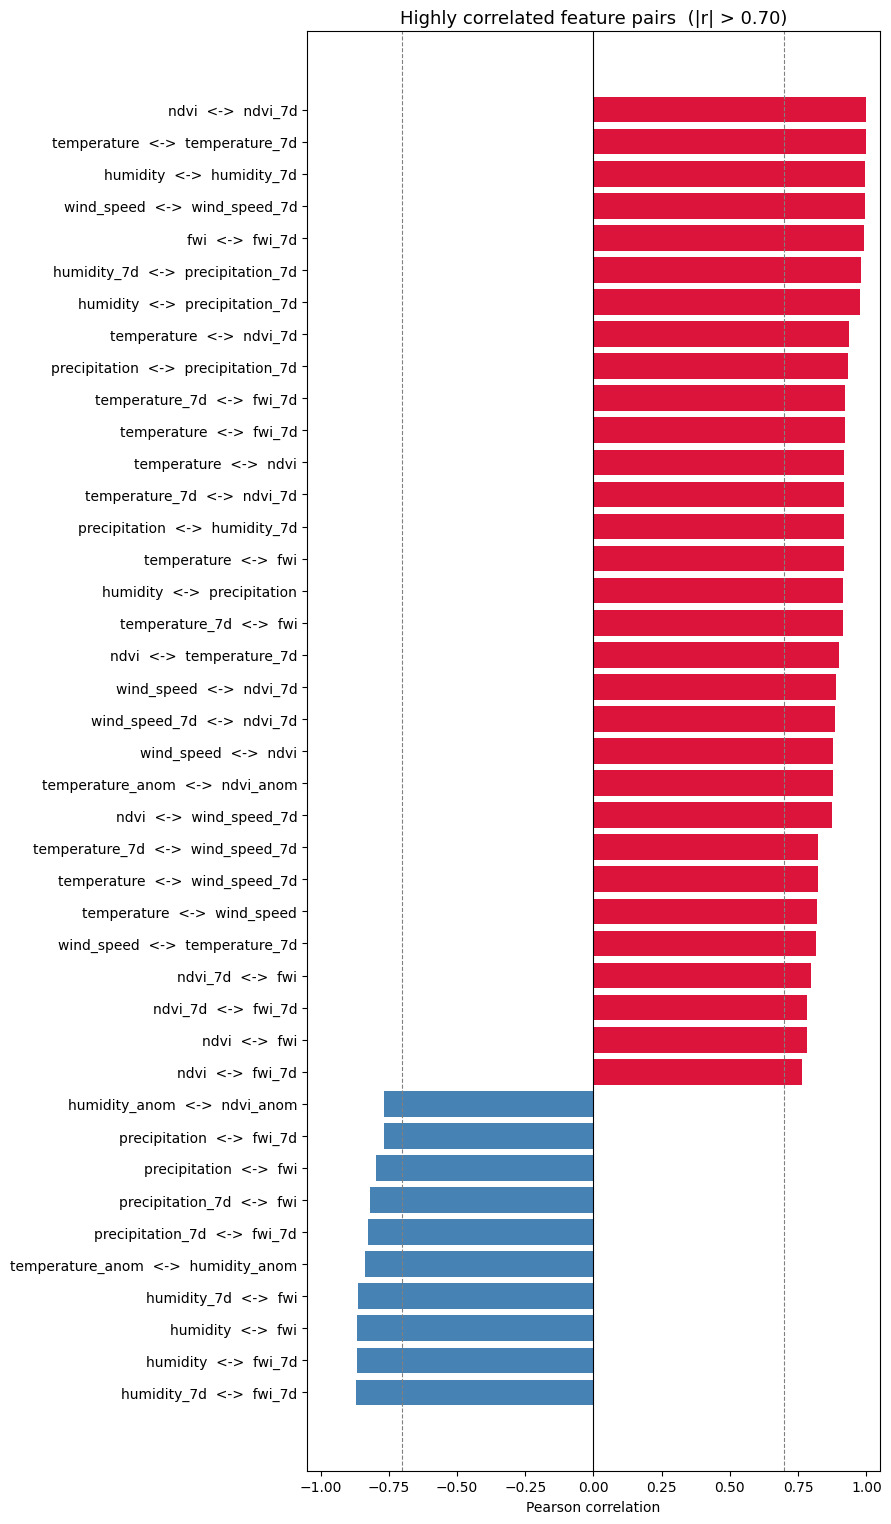

In [5]:
pairs = []
for i in range(len(NUMERIC)):
    for j in range(i + 1, len(NUMERIC)):
        c = corr.iloc[i, j]
        if abs(c) > 0.7:
            pairs.append((NUMERIC[i], NUMERIC[j], c))

pairs.sort(key=lambda x: x[2])
labels = [f'{a}  <->  {b}' for a, b, _ in pairs]
values = [c for _, _, c in pairs]
colors = ['crimson' if c > 0 else 'steelblue' for c in values]

fig, ax = plt.subplots(figsize=(9, len(pairs) * 0.35 + 1))
ax.barh(labels, values, color=colors)
ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline( 0.7, color='grey',  linewidth=0.8, linestyle='--')
ax.axvline(-0.7, color='grey',  linewidth=0.8, linestyle='--')
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel('Pearson correlation')
ax.set_title('Highly correlated feature pairs  (|r| > 0.70)', fontsize=13)
plt.tight_layout()
plt.show()

## Proposed reduced feature set

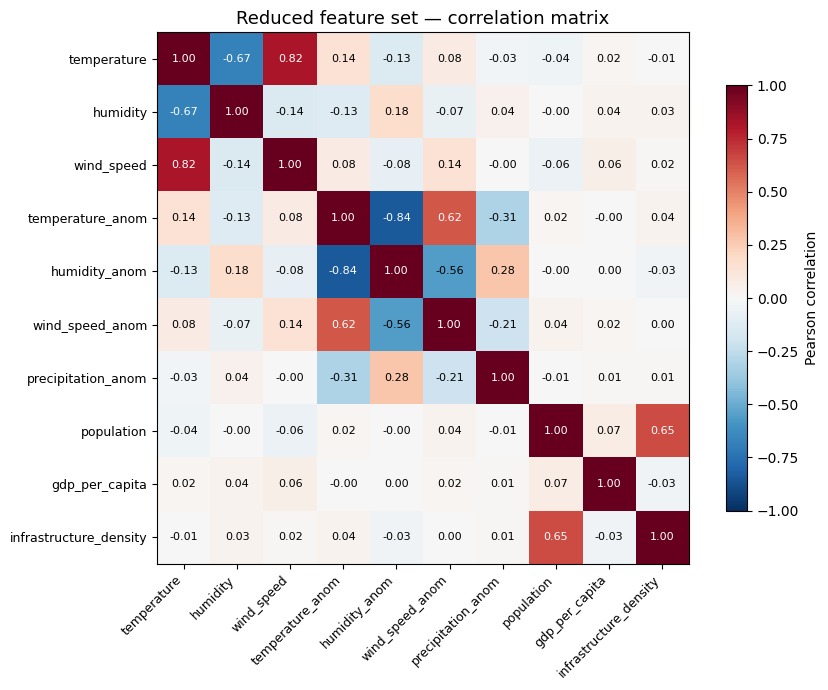

In [6]:
REDUCED = [
    'temperature',
    'humidity',
    'wind_speed',
    'temperature_anom',
    'humidity_anom',
    'wind_speed_anom',
    'precipitation_anom',
    'population',
    'gdp_per_capita',
    'infrastructure_density',
]

corr_reduced = df[REDUCED].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_reduced.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson correlation')

ax.set_xticks(range(len(REDUCED)))
ax.set_yticks(range(len(REDUCED)))
ax.set_xticklabels(REDUCED, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(REDUCED, fontsize=9)

for i in range(len(REDUCED)):
    for j in range(len(REDUCED)):
        val = corr_reduced.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('Reduced feature set — correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()